In [1]:
import os
import random
import time
import tracemalloc

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os

print(os.getcwd())

/Users/apple/Desktop/algorithm_efficiency_analysis


In [3]:
os.makedirs("results", exist_ok=True)
os.makedirs("graphs", exist_ok=True)
os.makedirs("word_files", exist_ok=True)

print("Project setup completed successfully!")

Project setup completed successfully!


In [4]:
def measure_performance(func, *args):
    tracemalloc.start()

    start_time = time.perf_counter()

    result = func(*args)

    end_time = time.perf_counter()

    current_memory, peak_memory = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    execution_time = end_time - start_time
    memory_usage_kb = peak_memory / 1024

    return result, execution_time, memory_usage_kb

Bubble sort

In [5]:
def bubble_sort(arr):
    arr = arr.copy()
    n = len(arr)

    for i in range(n):

        swapped = False

        for j in range(0, n - i - 1):

            if arr[j] > arr[j + 1]:

                arr[j], arr[j + 1] = arr[j + 1], arr[j]

                swapped = True

        # If no elements were swapped,
        # the array is already sorted
        if not swapped:
            break

    return arr

Insertion sort

In [6]:
def insertion_sort(arr):
    arr = arr.copy()

    for i in range(1, len(arr)):

        key = arr[i]

        j = i - 1

        while j >= 0 and arr[j] > key:

            arr[j + 1] = arr[j]

            j -= 1

        arr[j + 1] = key

    return arr

Merge sort

In [7]:
def merge(left, right):

    result = []

    i = 0
    j = 0

    while i < len(left) and j < len(right):

        if left[i] <= right[j]:

            result.append(left[i])
            i += 1

        else:

            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result

In [8]:
def merge_sort(arr):

    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)

Quick sort

In [19]:
def partition(arr, low, high):

    # Choose the middle element as pivot
    mid = (low + high) // 2

    # Move pivot to the end
    arr[mid], arr[high] = arr[high], arr[mid]

    pivot = arr[high]

    i = low - 1

    for j in range(low, high):

        if arr[j] <= pivot:

            i += 1

            arr[i], arr[j] = arr[j], arr[i]

    arr[i + 1], arr[high] = arr[high], arr[i + 1]

    return i + 1

In [10]:
def quick_sort_recursive(arr, low, high):

    if low < high:

        pivot_index = partition(arr, low, high)

        quick_sort_recursive(arr, low, pivot_index - 1)

        quick_sort_recursive(arr, pivot_index + 1, high)

In [11]:
def quick_sort(arr):

    arr = arr.copy()

    quick_sort_recursive(arr, 0, len(arr) - 1)

    return arr

Test all sorting algorithms 

In [20]:
test_data = [5, 2, 9, 1, 7, 3]

sorting_algorithms = {
    "Bubble Sort": bubble_sort,
    "Insertion Sort": insertion_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

for name, algorithm in sorting_algorithms.items():

    result = algorithm(test_data)

    print(name)
    print("Original:", test_data)
    print("Sorted:  ", result)
    print()

Bubble Sort
Original: [5, 2, 9, 1, 7, 3]
Sorted:   [1, 2, 3, 5, 7, 9]

Insertion Sort
Original: [5, 2, 9, 1, 7, 3]
Sorted:   [1, 2, 3, 5, 7, 9]

Merge Sort
Original: [5, 2, 9, 1, 7, 3]
Sorted:   [1, 2, 3, 5, 7, 9]

Quick Sort
Original: [5, 2, 9, 1, 7, 3]
Sorted:   [1, 2, 3, 5, 7, 9]



Generate input data

In [21]:
def generate_input_data(size):
    # Generate random data
    random_data = [random.randint(1, 100000) for _ in range(size)]

    # Create sorted data using the same values
    sorted_data = sorted(random_data)

    # Create reverse-sorted data using the same values
    reverse_sorted_data = sorted(random_data, reverse=True)

    return {
        "Sorted": sorted_data,
        "Reverse Sorted": reverse_sorted_data,
        "Random": random_data
    }

In [22]:
test_sizes = [100, 300, 500, 1000, 2000]

print("Test sizes:", test_sizes)

Test sizes: [100, 300, 500, 1000, 2000]


In [23]:
sorting_results = []

for size in test_sizes:

    print(f"\nTesting input size: {size}")

    input_conditions = generate_input_data(size)

    for condition, data in input_conditions.items():

        print(f"  Condition: {condition}")

        for algorithm_name, algorithm_function in sorting_algorithms.items():

            # Measure performance
            result, execution_time, memory_usage = measure_performance(
                algorithm_function,
                data
            )

            # Verify that the result is correctly sorted
            if result != sorted(data):
                print(f"    ERROR: {algorithm_name} did not sort correctly!")

            sorting_results.append({
                "Input Size": size,
                "Condition": condition,
                "Algorithm": algorithm_name,
                "Execution Time (seconds)": execution_time,
                "Memory Usage (KB)": memory_usage
            })

            print(
                f"    {algorithm_name}: "
                f"{execution_time:.6f} sec, "
                f"{memory_usage:.2f} KB"
            )


Testing input size: 100
  Condition: Sorted
    Bubble Sort: 0.000013 sec, 4201.83 KB
    Insertion Sort: 0.000019 sec, 0.87 KB
    Merge Sort: 0.000538 sec, 1.98 KB
    Quick Sort: 0.000174 sec, 0.87 KB
  Condition: Reverse Sorted
    Bubble Sort: 0.000549 sec, 0.91 KB
    Insertion Sort: 0.000271 sec, 0.87 KB
    Merge Sort: 0.000480 sec, 1.98 KB
    Quick Sort: 0.000172 sec, 0.87 KB
  Condition: Random
    Bubble Sort: 0.000442 sec, 0.91 KB
    Insertion Sort: 0.000128 sec, 0.87 KB
    Merge Sort: 0.000506 sec, 1.78 KB
    Quick Sort: 0.000177 sec, 0.87 KB

Testing input size: 300
  Condition: Sorted
    Bubble Sort: 0.000090 sec, 2.56 KB
    Insertion Sort: 0.000125 sec, 2.49 KB
    Merge Sort: 0.001626 sec, 5.89 KB
    Quick Sort: 0.001416 sec, 3.34 KB
  Condition: Reverse Sorted
    Bubble Sort: 0.009341 sec, 3.17 KB
    Insertion Sort: 0.005190 sec, 2.56 KB
    Merge Sort: 0.001612 sec, 5.89 KB
    Quick Sort: 0.001273 sec, 2.91 KB
  Condition: Random
    Bubble Sort: 0.006552 

In [24]:
sorting_df = pd.DataFrame(sorting_results)

sorting_df.head()

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
0,100,Sorted,Bubble Sort,0.000013,4201.833984
1,100,Sorted,Insertion Sort,0.000019,0.867188
2,100,Sorted,Merge Sort,0.000538,1.984375
3,100,Sorted,Quick Sort,0.000174,0.867188
4,100,Reverse Sorted,Bubble Sort,0.000549,0.906250


In [25]:
print("Total experiments completed:", len(sorting_df))

Total experiments completed: 60


In [26]:
sorting_df.to_csv(
    "results/sorting_results.csv",
    index=False
)

print("Sorting results saved successfully!")

Sorting results saved successfully!


Recursive Fibonacci 

In [27]:
def fib_recursive(n):
    if n <= 1:
        return n

    return fib_recursive(n - 1) + fib_recursive(n - 2)

Iterative Fibonacci 

In [28]:
def fib_iterative(n):
    if n <= 1:
        return n

    a, b = 0, 1

    for _ in range(2, n + 1):
        a, b = b, a + b

    return b

Dynamic Programming Fibonacci 

In [29]:
def fib_dp(n, memo=None):

    if memo is None:
        memo = {}

    if n in memo:
        return memo[n]

    if n <= 1:
        return n

    memo[n] = fib_dp(n - 1, memo) + fib_dp(n - 2, memo)

    return memo[n]

Test all three Fibonacci algorithms 

In [30]:
test_n = 10

print("Testing Fibonacci algorithms for n =", test_n)

print("Recursive:", fib_recursive(test_n))
print("Iterative:", fib_iterative(test_n))
print("Dynamic Programming:", fib_dp(test_n))

Testing Fibonacci algorithms for n = 10
Recursive: 55
Iterative: 55
Dynamic Programming: 55


In [31]:
fibonacci_algorithms = {
    "Recursive Fibonacci": fib_recursive,
    "Iterative Fibonacci": fib_iterative,
    "Dynamic Programming Fibonacci": fib_dp
}

In [32]:
fib_sizes = [5, 10, 15, 20, 25, 30, 35]

In [33]:
fibonacci_results = []

for n in fib_sizes:

    print(f"\nTesting Fibonacci for n = {n}")

    for algorithm_name, algorithm_function in fibonacci_algorithms.items():

        result, execution_time, memory_usage = measure_performance(
            algorithm_function,
            n
        )

        fibonacci_results.append({
            "Input Size (n)": n,
            "Algorithm": algorithm_name,
            "Fibonacci Value": result,
            "Execution Time (seconds)": execution_time,
            "Memory Usage (KB)": memory_usage
        })

        print(
            f"  {algorithm_name}: "
            f"Value = {result}, "
            f"Time = {execution_time:.6f} sec, "
            f"Memory = {memory_usage:.2f} KB"
        )


Testing Fibonacci for n = 5
  Recursive Fibonacci: Value = 5, Time = 0.000004 sec, Memory = 0.00 KB
  Iterative Fibonacci: Value = 5, Time = 0.000009 sec, Memory = 0.09 KB
  Dynamic Programming Fibonacci: Value = 5, Time = 0.000005 sec, Memory = 0.16 KB

Testing Fibonacci for n = 10
  Recursive Fibonacci: Value = 55, Time = 0.000013 sec, Memory = 0.00 KB
  Iterative Fibonacci: Value = 55, Time = 0.000004 sec, Memory = 0.09 KB
  Dynamic Programming Fibonacci: Value = 55, Time = 0.000016 sec, Memory = 0.44 KB

Testing Fibonacci for n = 15
  Recursive Fibonacci: Value = 610, Time = 0.000181 sec, Memory = 0.06 KB
  Iterative Fibonacci: Value = 610, Time = 0.000010 sec, Memory = 0.10 KB
  Dynamic Programming Fibonacci: Value = 610, Time = 0.000016 sec, Memory = 0.84 KB

Testing Fibonacci for n = 20
  Recursive Fibonacci: Value = 6765, Time = 0.001900 sec, Memory = 0.16 KB
  Iterative Fibonacci: Value = 6765, Time = 0.000021 sec, Memory = 0.13 KB
  Dynamic Programming Fibonacci: Value = 676

In [34]:
fibonacci_df = pd.DataFrame(fibonacci_results)

fibonacci_df

,Input Size (n),Algorithm,Fibonacci Value,Execution Time (seconds),Memory Usage (KB)
0,5,Recursive Fibonacci,5,0.000004,0.000000
1,5,Iterative Fibonacci,5,0.000009,0.085938
2,5,Dynamic Programming Fibonacci,5,0.000005,0.156250
3,10,Recursive Fibonacci,55,0.000013,0.000000
4,10,Iterative Fibonacci,55,0.000004,0.085938
5,10,Dynamic Programming Fibonacci,55,0.000016,0.437500
6,15,Recursive Fibonacci,610,0.000181,0.062500
7,15,Iterative Fibonacci,610,0.000010,0.101562
8,15,Dynamic Programming Fibonacci,610,0.000016,0.835938
9,20,Recursive Fibonacci,6765,0.001900,0.156250


In [35]:
print("Total Fibonacci experiments:", len(fibonacci_df))

Total Fibonacci experiments: 21


In [36]:
fibonacci_df.to_csv(
    "results/fibonacci_results.csv",
    index=False
)

print("Fibonacci results saved successfully!")

Fibonacci results saved successfully!


Complexity Table

In [37]:
complexity_data = {
    "Algorithm": [
        "Bubble Sort",
        "Insertion Sort",
        "Merge Sort",
        "Quick Sort",
        "Recursive Fibonacci",
        "Iterative Fibonacci",
        "Dynamic Programming Fibonacci"
    ],

    "Best Case": [
        "O(n)",
        "O(n)",
        "O(n log n)",
        "O(n log n)",
        "O(2^n)",
        "O(n)",
        "O(n)"
    ],

    "Average Case": [
        "O(n²)",
        "O(n²)",
        "O(n log n)",
        "O(n log n)",
        "O(2^n)",
        "O(n)",
        "O(n)"
    ],

    "Worst Case": [
        "O(n²)",
        "O(n²)",
        "O(n log n)",
        "O(n²)",
        "O(2^n)",
        "O(n)",
        "O(n)"
    ],

    "Space Complexity": [
        "O(1)",
        "O(1)",
        "O(n)",
        "O(log n)",
        "O(n)",
        "O(1)",
        "O(n)"
    ]
}

complexity_df = pd.DataFrame(complexity_data)

complexity_df

,Algorithm,Best Case,Average Case,Worst Case,Space Complexity
0,Bubble Sort,O(n),O(n²),O(n²),O(1)
1,Insertion Sort,O(n),O(n²),O(n²),O(1)
2,Merge Sort,O(n log n),O(n log n),O(n log n),O(n)
3,Quick Sort,O(n log n),O(n log n),O(n²),O(log n)
4,Recursive Fibonacci,O(2^n),O(2^n),O(2^n),O(n)
5,Iterative Fibonacci,O(n),O(n),O(n),O(1)
6,Dynamic Programming Fibonacci,O(n),O(n),O(n),O(n)


In [38]:
complexity_df.to_csv(
    "results/complexity_comparison.csv",
    index=False
)

print("Complexity comparison table saved successfully!")

Complexity comparison table saved successfully!


In [39]:
print("COMPLEXITY COMPARISON TABLE")

display(complexity_df)

COMPLEXITY COMPARISON TABLE


,Algorithm,Best Case,Average Case,Worst Case,Space Complexity
0,Bubble Sort,O(n),O(n²),O(n²),O(1)
1,Insertion Sort,O(n),O(n²),O(n²),O(1)
2,Merge Sort,O(n log n),O(n log n),O(n log n),O(n)
3,Quick Sort,O(n log n),O(n log n),O(n²),O(log n)
4,Recursive Fibonacci,O(2^n),O(2^n),O(2^n),O(n)
5,Iterative Fibonacci,O(n),O(n),O(n),O(1)
6,Dynamic Programming Fibonacci,O(n),O(n),O(n),O(n)


Sorting Execution Time Graph


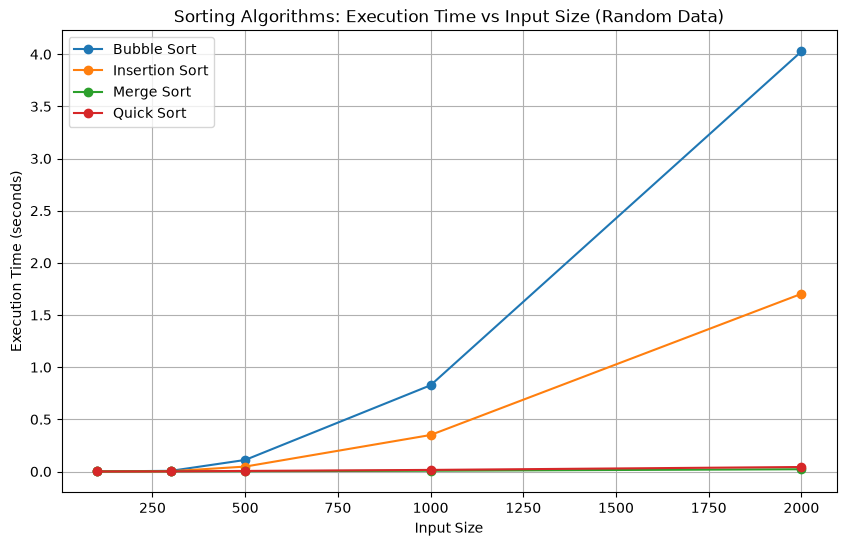

In [40]:
# Filter results for Random input condition
random_sorting_df = sorting_df[
    sorting_df["Condition"] == "Random"
]

plt.figure(figsize=(10, 6))

for algorithm in random_sorting_df["Algorithm"].unique():

    algorithm_data = random_sorting_df[
        random_sorting_df["Algorithm"] == algorithm
    ]

    plt.plot(
        algorithm_data["Input Size"],
        algorithm_data["Execution Time (seconds)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Sorting Algorithms: Execution Time vs Input Size (Random Data)")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/sorting_execution_time_random.png",
    bbox_inches="tight"
)

plt.show()

Sorting Memory Usage Graph

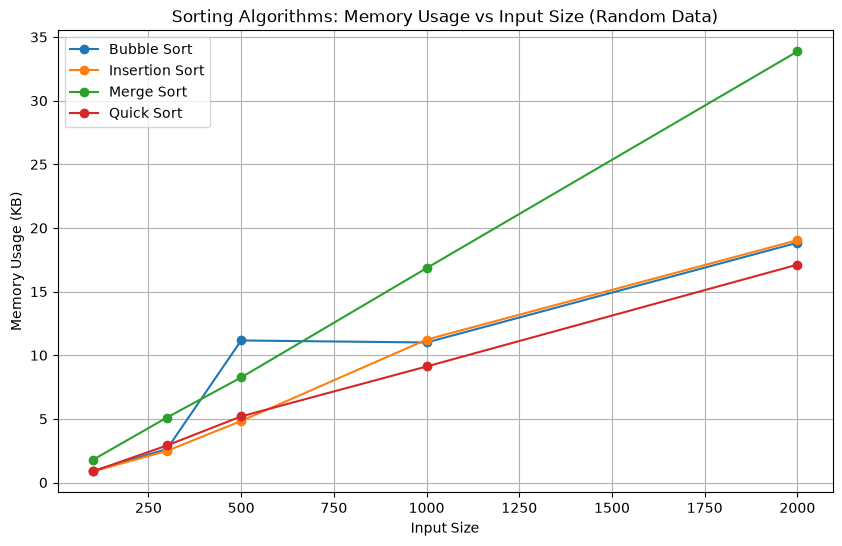

In [41]:
# Filter results for Random input condition
random_sorting_df = sorting_df[
    sorting_df["Condition"] == "Random"
]

plt.figure(figsize=(10, 6))

for algorithm in random_sorting_df["Algorithm"].unique():

    algorithm_data = random_sorting_df[
        random_sorting_df["Algorithm"] == algorithm
    ]

    plt.plot(
        algorithm_data["Input Size"],
        algorithm_data["Memory Usage (KB)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size")
plt.ylabel("Memory Usage (KB)")
plt.title("Sorting Algorithms: Memory Usage vs Input Size (Random Data)")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/sorting_memory_usage_random.png",
    bbox_inches="tight"
)

plt.show()

Compare Input Conditions 

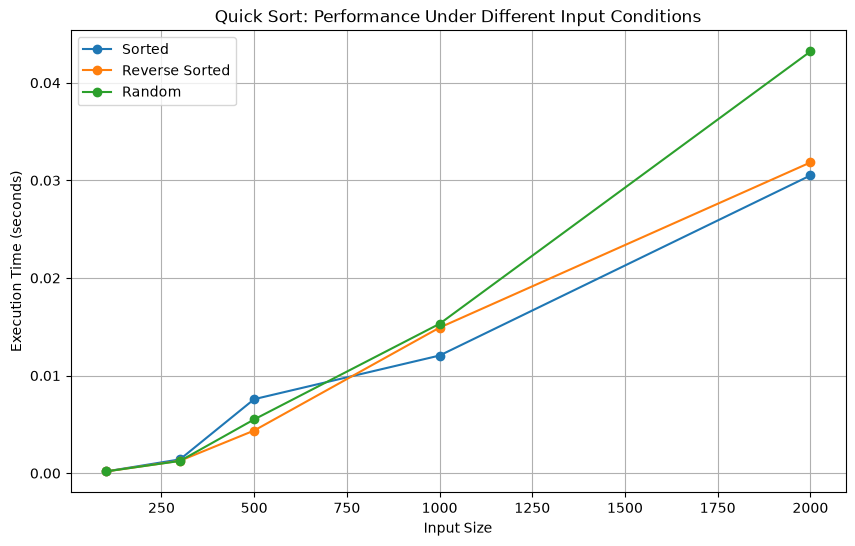

In [42]:
quick_sort_df = sorting_df[
    sorting_df["Algorithm"] == "Quick Sort"
]

plt.figure(figsize=(10, 6))

for condition in quick_sort_df["Condition"].unique():

    condition_data = quick_sort_df[
        quick_sort_df["Condition"] == condition
    ]

    plt.plot(
        condition_data["Input Size"],
        condition_data["Execution Time (seconds)"],
        marker="o",
        label=condition
    )

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Quick Sort: Performance Under Different Input Conditions")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/quick_sort_conditions.png",
    bbox_inches="tight"
)

plt.show()

Condition Comparison Graphs for All Sorting Algorithms

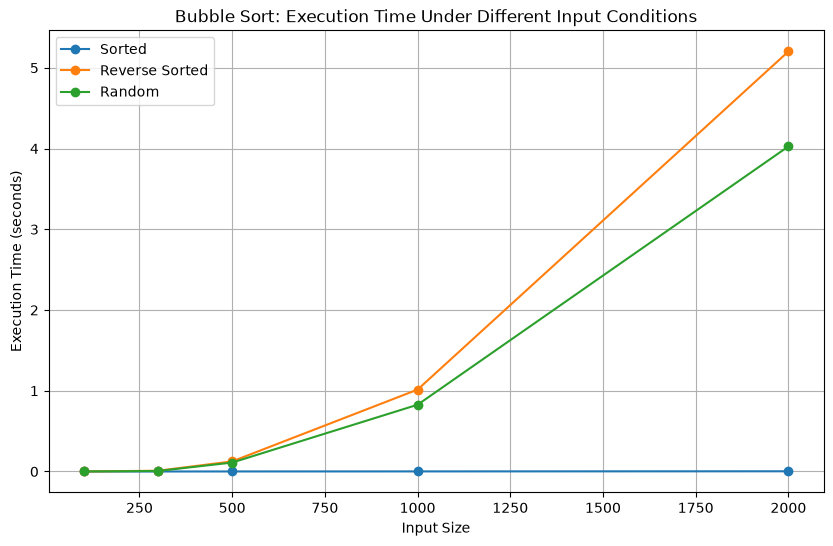

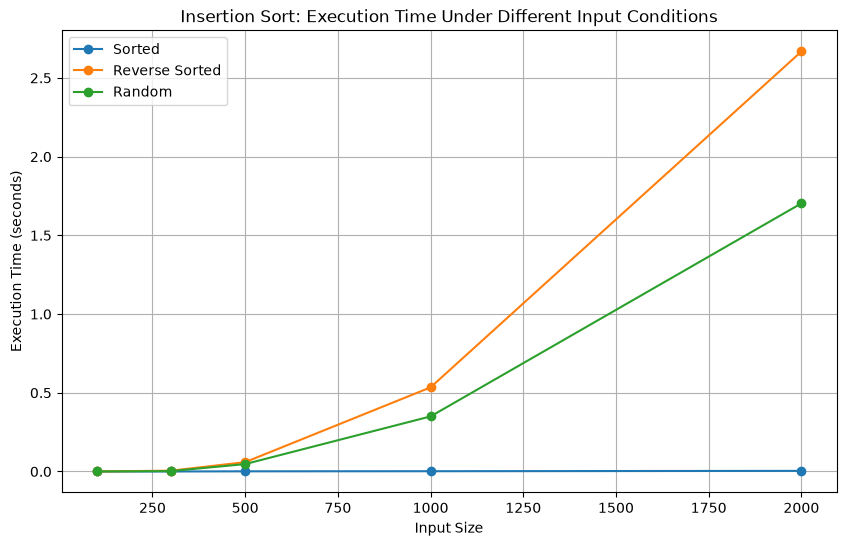

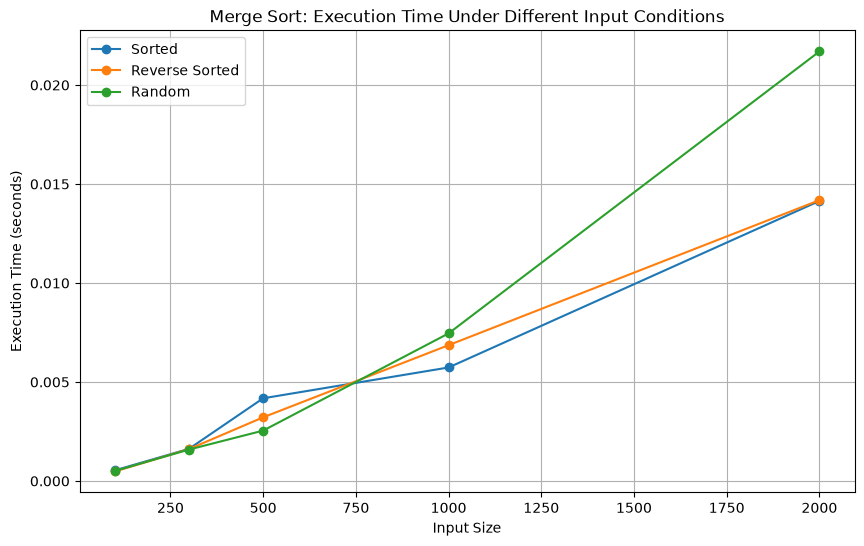

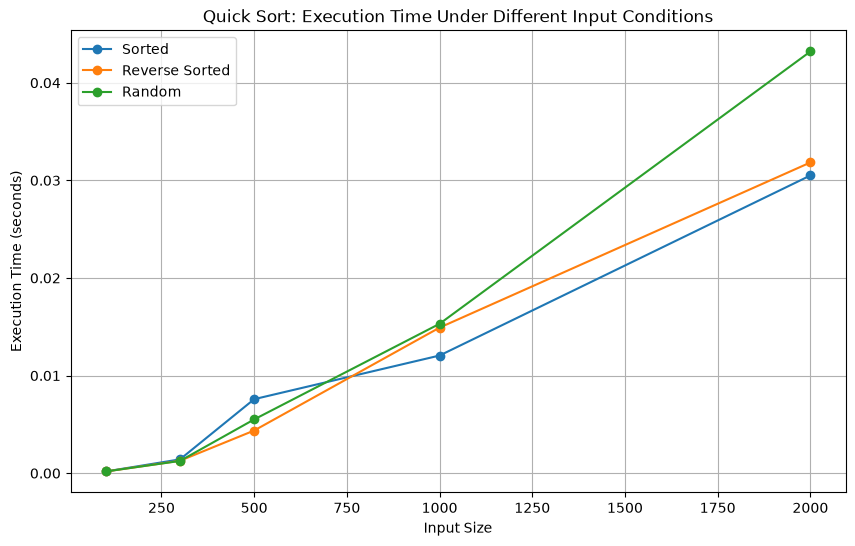

In [43]:
for algorithm in sorting_df["Algorithm"].unique():

    algorithm_df = sorting_df[
        sorting_df["Algorithm"] == algorithm
    ]

    plt.figure(figsize=(10, 6))

    for condition in algorithm_df["Condition"].unique():

        condition_data = algorithm_df[
            algorithm_df["Condition"] == condition
        ]

        plt.plot(
            condition_data["Input Size"],
            condition_data["Execution Time (seconds)"],
            marker="o",
            label=condition
        )

    plt.xlabel("Input Size")
    plt.ylabel("Execution Time (seconds)")
    plt.title(
        f"{algorithm}: Execution Time Under Different Input Conditions"
    )

    plt.legend()
    plt.grid(True)

    filename = algorithm.lower().replace(" ", "_")

    plt.savefig(
        f"graphs/{filename}_conditions.png",
        bbox_inches="tight"
    )

    plt.show()

Fibonacci Execution Time Graph

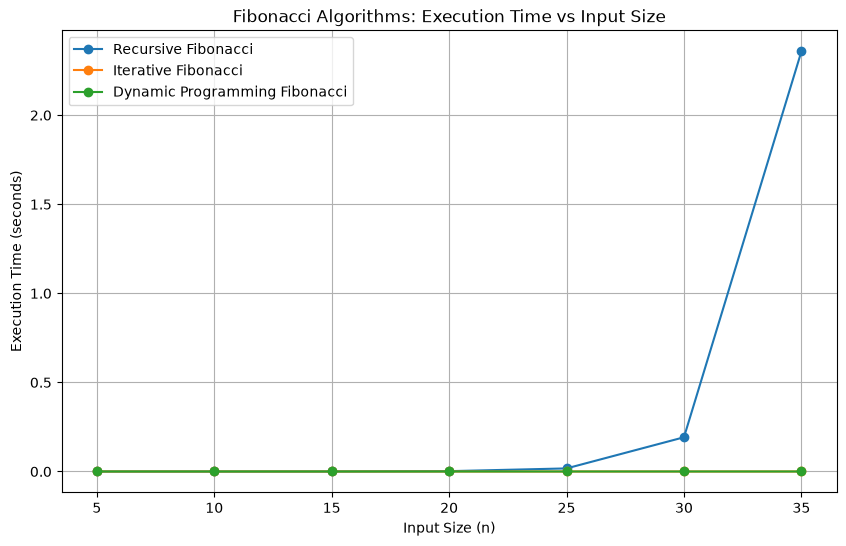

In [44]:
plt.figure(figsize=(10, 6))

for algorithm in fibonacci_df["Algorithm"].unique():

    algorithm_data = fibonacci_df[
        fibonacci_df["Algorithm"] == algorithm
    ]

    plt.plot(
        algorithm_data["Input Size (n)"],
        algorithm_data["Execution Time (seconds)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Fibonacci Algorithms: Execution Time vs Input Size")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/fibonacci_execution_time.png",
    bbox_inches="tight"
)

plt.show()

Fibonacci Memory Usage Graph

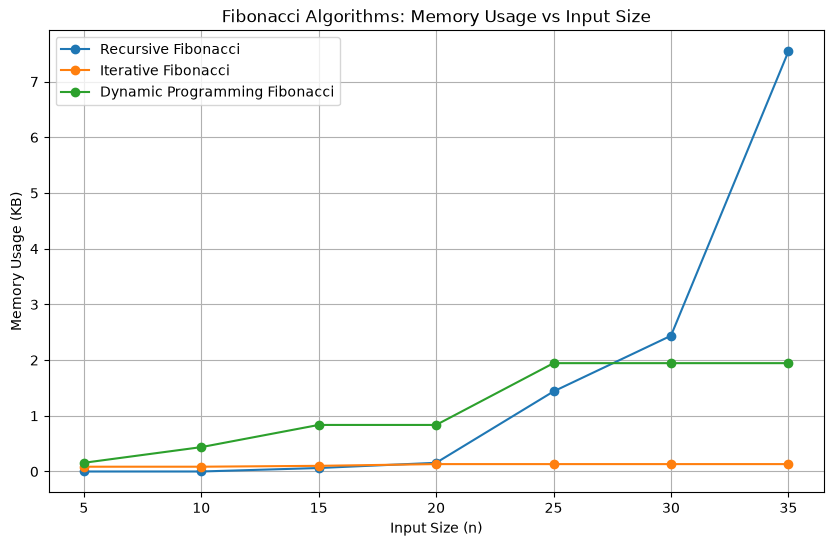

In [46]:
plt.figure(figsize=(10, 6))

for algorithm in fibonacci_df["Algorithm"].unique():

    algorithm_data = fibonacci_df[
        fibonacci_df["Algorithm"] == algorithm
    ]

    plt.plot(
        algorithm_data["Input Size (n)"],
        algorithm_data["Memory Usage (KB)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size (n)")
plt.ylabel("Memory Usage (KB)")
plt.title("Fibonacci Algorithms: Memory Usage vs Input Size")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/fibonacci_memory_usage.png",
    bbox_inches="tight"
)

plt.show()

In [47]:
import os

graph_files = os.listdir("graphs")

print("Generated Graph Files:")

for file in graph_files:
    print("-", file)

Generated Graph Files:
- bubble_sort_conditions.png
- fibonacci_execution_time.png
- merge_sort_conditions.png
- quick_sort_conditions.png
- fibonacci_memory_usage.png
- sorting_execution_time_random.png
- insertion_sort_conditions.png
- sorting_memory_usage_random.png


# Observations

## Sorting Algorithms

1. Bubble Sort and Insertion Sort show increasing execution time as the input size increases because their average and worst-case time complexity is O(n²).

2. Bubble Sort performs efficiently on already sorted data because the optimized implementation stops when no swaps occur.

3. Insertion Sort generally performs better on sorted or nearly sorted data because fewer element shifts are required.

4. Merge Sort provides more consistent performance across sorted, reverse-sorted, and random input conditions because its time complexity remains O(n log n).

5. Quick Sort performance depends on pivot selection and input distribution. The experimental implementation uses a middle-element pivot to reduce the possibility of highly unbalanced partitions.

6. Merge Sort generally requires more memory because additional arrays are used during the merging process.

## Fibonacci Algorithms

1. Recursive Fibonacci becomes significantly slower as the value of n increases because the same subproblems are calculated repeatedly.

2. Iterative Fibonacci maintains efficient performance because each Fibonacci value is calculated only once.

3. Dynamic Programming Fibonacci avoids repeated calculations by storing previously computed values.

4. Recursive Fibonacci uses additional memory due to recursive function calls.

5. Iterative Fibonacci generally requires the least additional memory because it only stores a small number of variables.

6. Dynamic Programming Fibonacci may use more memory than the iterative approach because it stores computed values in a memoization structure.

7. The experimental results demonstrate that algorithm design and implementation strategy can significantly affect execution time and memory consumption.

# Conclusion

The experimental analysis demonstrates the relationship between theoretical algorithm complexity and practical performance.

For sorting algorithms, Bubble Sort and Insertion Sort become slower as the input size increases due to their quadratic time complexity. Merge Sort provides more consistent O(n log n) performance across different input conditions but requires additional memory. Quick Sort can provide efficient performance depending on pivot selection and input distribution.

For Fibonacci algorithms, Recursive Fibonacci becomes inefficient for larger input values because it repeatedly solves the same subproblems. Iterative Fibonacci provides efficient computation with minimal additional memory. Dynamic Programming improves performance by storing previously computed results and avoiding repeated calculations.

Overall, the experiments demonstrate that both input size and input conditions affect algorithm performance. The results also show the importance of selecting appropriate algorithms based on time complexity, space complexity, and characteristics of the input data.

Sorted Data

In [50]:
sorting_df[sorting_df["Condition"] == "Sorted"]

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
0,100,Sorted,Bubble Sort,0.000013,4201.833984
1,100,Sorted,Insertion Sort,0.000019,0.867188
2,100,Sorted,Merge Sort,0.000538,1.984375
3,100,Sorted,Quick Sort,0.000174,0.867188
12,300,Sorted,Bubble Sort,0.000090,2.558594
13,300,Sorted,Insertion Sort,0.000125,2.488281
14,300,Sorted,Merge Sort,0.001626,5.890625
15,300,Sorted,Quick Sort,0.001416,3.335938
24,500,Sorted,Bubble Sort,0.000632,4.121094
25,500,Sorted,Insertion Sort,0.001181,4.050781


Reverse Sorted Data

In [51]:
sorting_df[sorting_df["Condition"] == "Reverse Sorted"]

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
4,100,Reverse Sorted,Bubble Sort,0.000549,0.906250
5,100,Reverse Sorted,Insertion Sort,0.000271,0.867188
6,100,Reverse Sorted,Merge Sort,0.000480,1.984375
7,100,Reverse Sorted,Quick Sort,0.000172,0.867188
16,300,Reverse Sorted,Bubble Sort,0.009341,3.170898
17,300,Reverse Sorted,Insertion Sort,0.005190,2.562500
18,300,Reverse Sorted,Merge Sort,0.001612,5.890625
19,300,Reverse Sorted,Quick Sort,0.001273,2.914062
28,500,Reverse Sorted,Bubble Sort,0.124925,5.297852
29,500,Reverse Sorted,Insertion Sort,0.059417,4.050781


Random Data

In [53]:
sorting_df[sorting_df["Condition"] == "Random"]

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
8,100,Random,Bubble Sort,0.000442,0.906250
9,100,Random,Insertion Sort,0.000128,0.867188
10,100,Random,Merge Sort,0.000506,1.781250
11,100,Random,Quick Sort,0.000177,0.867188
20,300,Random,Bubble Sort,0.006552,2.636719
21,300,Random,Insertion Sort,0.002787,2.488281
22,300,Random,Merge Sort,0.001589,5.109375
23,300,Random,Quick Sort,0.001254,2.914062
32,500,Random,Bubble Sort,0.110758,11.162109
33,500,Random,Insertion Sort,0.047155,4.834961


In [54]:
fibonacci_df

,Input Size (n),Algorithm,Fibonacci Value,Execution Time (seconds),Memory Usage (KB)
0,5,Recursive Fibonacci,5,0.000004,0.000000
1,5,Iterative Fibonacci,5,0.000009,0.085938
2,5,Dynamic Programming Fibonacci,5,0.000005,0.156250
3,10,Recursive Fibonacci,55,0.000013,0.000000
4,10,Iterative Fibonacci,55,0.000004,0.085938
5,10,Dynamic Programming Fibonacci,55,0.000016,0.437500
6,15,Recursive Fibonacci,610,0.000181,0.062500
7,15,Iterative Fibonacci,610,0.000010,0.101562
8,15,Dynamic Programming Fibonacci,610,0.000016,0.835938
9,20,Recursive Fibonacci,6765,0.001900,0.156250


In [55]:
complexity_df

,Algorithm,Best Case,Average Case,Worst Case,Space Complexity
0,Bubble Sort,O(n),O(n²),O(n²),O(1)
1,Insertion Sort,O(n),O(n²),O(n²),O(1)
2,Merge Sort,O(n log n),O(n log n),O(n log n),O(n)
3,Quick Sort,O(n log n),O(n log n),O(n²),O(log n)
4,Recursive Fibonacci,O(2^n),O(2^n),O(2^n),O(n)
5,Iterative Fibonacci,O(n),O(n),O(n),O(1)
6,Dynamic Programming Fibonacci,O(n),O(n),O(n),O(n)


graphs/sorting_execution_time_random.png